**Работу выполнила Белозерова Ольга**

# **Прогнозирование заработной платы сотрудников**

## **Выбор ансамблевой модели**

**В качестве сложной ансамблевой модели** для решения задачи **был выбран Random Forest (случайный лес)** - метод бэггинга, основанный на построении множества деревьев решений, каждое из которых обучается на случайной подвыборке данных со случайным подмножеством признаков для каждого разбиения, а итоговый прогноз формируется как усреднение предсказаний всех деревьев. Данный ансамбль был выбран по нескольким причинам: во-первых, он позволит обнаружить потенциальные сложные нелинейные связи и взаимодействия между признаками, которые могли остаться незамеченными при парном анализе на этапе EDA; во-вторых, Random Forest устойчив к выбросам, которые были сознательно сохранены у целевой переменной как отражающие реальную рыночную вариативность зарплат, и при этом не требует масштабирования признаков, что значительно упрощает предобработку данных; в-третьих, в отличие от градиентного бустинга, Random Forest менее склонен к переобучению при сопоставимой предсказательной силе.

## **Загрузка данных**

Загружаем сохранённый датасет с предобработкой, произведенной на этапе EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Загружаем сохранённый датасет
df_final = pd.read_csv("/content/employee_salary_data_clean.csv")

print(f"Размер датасета: {df_final.shape[0]} строк, {df_final.shape[1]} столбцов")

print("\nПервые 5 строк датасета:")
df_final.head()

Размер датасета: 249860 строк, 9 столбцов

Первые 5 строк датасета:


,job_title,experience_years,education_level,skills_count,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Large,Sweden,Yes,0,165069


**Выбор признаков для модели**

**Для построения ансамблевой модели используются все восемь признаков**, оставшихся после этапа EDA и **применявшихся при обучении линейной регрессии**. Такое решение преследует две цели: сохранить максимальный объём доступной информации и учесть потенциальные взаимодействия между переменными, а также обеспечить корректное сравнение качества моделей за счёт использования одинакового набора признаков.

## **Разбиение датасета на train и test выборки**

Для обеспечения корректного сравнения с моделью линейной регрессии **повторяем разбиение датасета на обучающую и тестовую выборки строго тем же способом**, который использовался ранее, **и фиксируем тот же параметр random_state = 2026** для воспроизводимости результатов.

In [3]:
from sklearn.model_selection import train_test_split

# Отделяем целевую переменную от признаков
X = df_final.drop('salary', axis=1)
y = df_final['salary']

# Разбиваем на train и test выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026)

### **Проверка сопоставимости распределений в тренировочной и тестовой выборках**

При разбиении датасета на тренировочную и тестовую выборки важно проверить сопоставимость распределений в них, поскольку если распределения значительно различаются, то модель будет оцениваться на данных, для которых она изначально не была оптимизирована, что приведёт к некорректной оценке её обобщающей способности и создаст ложное впечатление о реальной эффективности. Сопоставимость выборок гарантирует, что тестовые данные отражают структуру генеральной совокупности, с которой модель столкнётся в реальной эксплуатации, а полученные метрики качества объективно характеризуют её способность к обобщению.

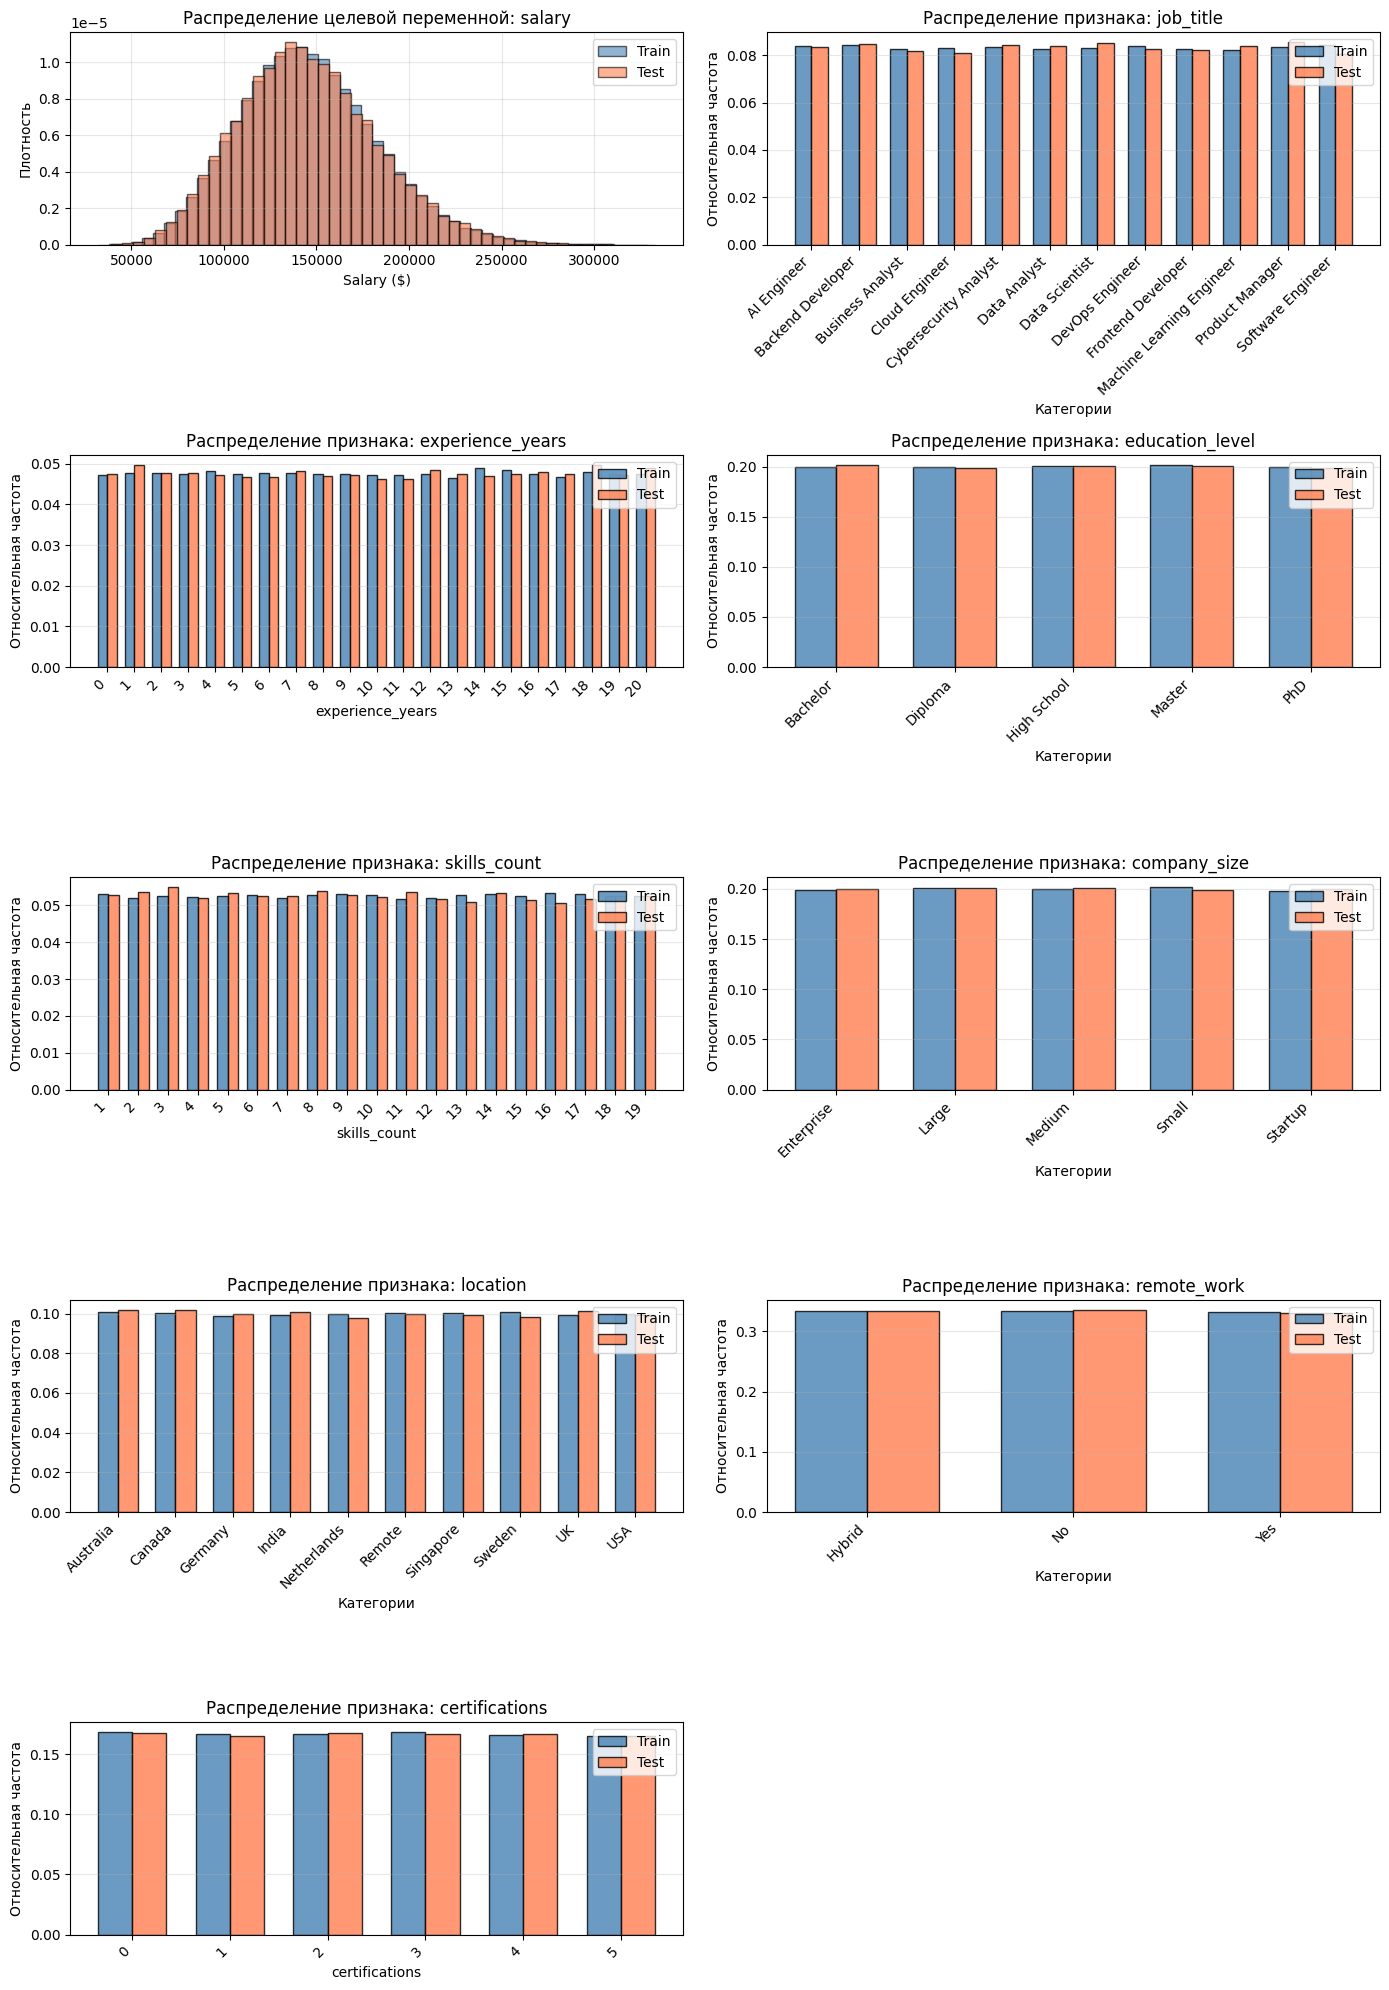

In [4]:
# Определяем список всех признаков (исключая целевую переменную)
all_features = X_train.columns.tolist()

# Определяем количество графиков: по одному на каждый признак + целевая переменная
n_plots = len(all_features) + 1
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols

# Создаём фигуру с подграфиками
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

# Счётчик для индексации подграфиков
plot_idx = 0

# 1. Сравнение распределения целевой переменной salary (гистограмма)
ax = axes[plot_idx]
ax.hist(y_train, bins=50, alpha=0.6, color='steelblue', edgecolor='black', label='Train', density=True)
ax.hist(y_test, bins=50, alpha=0.6, color='coral', edgecolor='black', label='Test', density=True)
ax.set_xlabel('Salary ($)')
ax.set_ylabel('Плотность')
ax.set_title('Распределение целевой переменной: salary')
ax.legend()
ax.grid(True, alpha=0.3)
plot_idx += 1

# 2. Сравнение распределения признаков
for feature in all_features:
    ax = axes[plot_idx]

    # Проверяем тип данных признака
    if X_train[feature].dtype in ['int64', 'float64']:
        # Для числовых признаков используем столбчатую диаграмму с относительными частотами
        train_counts = X_train[feature].value_counts(normalize=True).sort_index()
        test_counts = X_test[feature].value_counts(normalize=True).sort_index()

        all_values = sorted(set(train_counts.index) | set(test_counts.index))
        train_aligned = [train_counts.get(val, 0) for val in all_values]
        test_aligned = [test_counts.get(val, 0) for val in all_values]

        x = np.arange(len(all_values))
        width = 0.35

        ax.bar(x - width/2, train_aligned, width, label='Train', alpha=0.8, color='steelblue', edgecolor='black')
        ax.bar(x + width/2, test_aligned, width, label='Test', alpha=0.8, color='coral', edgecolor='black')
        ax.set_xlabel(feature)
        ax.set_ylabel('Относительная частота')
        ax.set_title(f'Распределение признака: {feature}')
        ax.set_xticks(x)
        ax.set_xticklabels(all_values, rotation=45, ha='right')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

    else:
        # Для категориальных признаков используем столбчатую диаграмму
        train_counts = X_train[feature].value_counts(normalize=True)
        test_counts = X_test[feature].value_counts(normalize=True)

        all_categories = sorted(set(train_counts.index) | set(test_counts.index))
        train_aligned = [train_counts.get(cat, 0) for cat in all_categories]
        test_aligned = [test_counts.get(cat, 0) for cat in all_categories]

        x = np.arange(len(all_categories))
        width = 0.35

        ax.bar(x - width/2, train_aligned, width, label='Train', alpha=0.8, color='steelblue', edgecolor='black')
        ax.bar(x + width/2, test_aligned, width, label='Test', alpha=0.8, color='coral', edgecolor='black')
        ax.set_xlabel('Категории')
        ax.set_ylabel('Относительная частота')
        ax.set_title(f'Распределение признака: {feature}')
        ax.set_xticks(x)
        ax.set_xticklabels(all_categories, rotation=45, ha='right')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

    plot_idx += 1

# Скрываем неиспользуемые подграфики
for idx in range(plot_idx, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

**Вывод:** Распределения всех переменных в тренировочной и тестовой выборках демонстрируют высокую степень схожести и полную сопоставимость.

## **Предобработка признаков для Random Forest**

**Единственная обязательная предобработка признаков перед подачей в модель Random Forest - кодирование категориальных переменных в числовой формат**, так как алгоритм работает только с числами. Поскольку в датасете присутствуют как порядковые, так и номинальные категориальные переменные, для каждой группы применяется соответствующий метод кодирования. **Для порядковых признаков education_level и company_size, где уровни образования (High School → Diploma → Bachelor → Master → PhD) и размеры компаний (Startup → Small → Medium → Large → Enterprise) обладают естественной иерархией, используется Ordinal Encoding**, позволяющий сохранить порядковую структуру данных. **Для номинальных признаков с невысокой кардинальностью - remote_work (3 уникальных значения), location (10 уникальных значений) и job_title (12 уникальных значений) - применяется One-Hot Encoding**, который создаёт отдельные бинарные признаки для каждой категории.

В отличие от линейной регрессии, **Random Forest не требует масштабирования числовых признаков** (experience_years, skills_count, certifications), поскольку деревья решений используют пороговые разбиения, а не вычисляют расстояния, поэтому разница в масштабах признаков никак не влияет на построение модели.



In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Определяем группы признаков
numerical_features = ['experience_years', 'skills_count', 'certifications']
categorical_ordinal = ['education_level', 'company_size']
categorical_nominal = ['job_title', 'location', 'remote_work']

# Задаём порядок для порядковых признаков
education_order = ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']
company_size_order = ['Startup', 'Small', 'Medium', 'Large', 'Enterprise']

# Создаём ColumnTransformer для предобработки разных групп признаков
preprocessor = ColumnTransformer(
    transformers=[
        # Числовые признаки пропускаем без изменений
        ('num', 'passthrough', numerical_features),

        # OrdinalEncoding для порядковых признаков
        ('ord', OrdinalEncoder(categories=[education_order, company_size_order]), categorical_ordinal),

        # One-Hot Encoding для номинальных признаков
        ('nom', OneHotEncoder(drop='first', sparse_output=False), categorical_nominal)
    ]
)

# Создаём пайплайн: сначала предобработка признаков, затем модель Random Forest
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=2026))
])

## **Выбор оптимальных значений гиперпараметров модели Random Forest**

**Осуществим подбор гиперпараметров, чтобы найти оптимальную конфигурацию модели, обеспечивающую оптимальный баланс между точностью предсказаний и устойчивостью к переобучению**.

**Основные гиперпараметры Random Forest для оптимизации**

1) **n_estimators - количество деревьев в ансамбле**

**Чем больше деревьев, тем стабильнее и точнее предсказания**, однако с ростом их количества увеличивается время обучения, а после определённого порога улучшение качества становится незначительным. Настройка этого параметра важна, поскольку **слишком малое количество деревьев приводит к недообучению** и нестабильности модели, тогда как **избыточное - к неоправданным вычислительным затратам без существенного выигрыша в качестве**.

2) **max_depth - максимальная глубина дерева**

Этот гиперпараметр ограничивает сложность каждого дерева, задавая максимальное количество уровней от корня до листа. **Чем глубже дерево, тем больше деталей оно может запомнить, что повышает риск переобучения**. Настройка критически важна, поскольку **слишком малая глубина приводит к недообучению, а слишком большая - к переобучению**, когда модель запоминает случайные шумы и выбросы.

3) **min_samples_split - минимальное количество примеров для разбиения узла**

Этот параметр определяет, сколько объектов должно быть в узле, чтобы разрешить его дальнейшее разбиение. **Чем выше значение, тем более общие правила формирует модель, поскольку разбиение разрешается только при достаточном количестве примеров**. Оптимизация важна, так как параметр **предотвращает создание узлов с очень малым количеством объектов, что снижает риск переобучения** и повышает устойчивость модели.

4) **max_features - количество признаков для поиска лучшего разбиения**

Этот гиперпараметр определяет, сколько случайно выбранных признаков рассматривается при каждом разбиении узла. **Меньшее значение увеличивает разнообразие деревьев в ансамбле и снижает корреляцию между ними, что улучшает обобщающую способность ансамбля**. Оптимизация критически важна, поскольку неправильный выбор может привести либо к слишком похожим деревьям, либо к чрезмерно слабым деревьям, неспособным уловить важные закономерности.

**В целях экономии вычислительных ресурсов** и преодоления ошибки нехватки места на диске в Colab мы **исключим гиперпараметр min_samples_leaf из процесса оптимизации и оставим его со значением по умолчанию**. **Этот гиперпараметр** задаёт минимальное количество примеров в листе дерева и **во многом дублирует функцию min_samples_split, с той разницей, что действует на уровне листьев, а не узлов**. **При правильно подобранных значениях max_depth и min_samples_split настройка min_samples_leaf даёт лишь незначительный прирост качества, поэтому его исключение не приведёт к существенной потере точности модели**, но позволит сократить количество комбинаций гиперпараметров и избежать ошибок из-за нехватки памяти.

**Создадим сетку значений гиперпараметров для Random Forest, которые будут тестироваться в процессе поиска оптимальной конфигурации модели**. Это позволяет автоматически перебрать различные комбинации гиперпараметров и выбрать ту, которая обеспечивает наилучшее качество прогнозирования.


In [6]:
# Сетка гиперпараметров для Random Forest
param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [20, 30, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__max_features': [0.3, 0.5]
}

**Для подбора оптимальных гиперпараметров модели Random Forest воспользуемся методом HalvingGridSearchCV из библиотеки scikit-learn, который последовательно сокращает количество кандидатов**. На каждом этапе модели с различными комбинациями гиперпараметров обучаются на небольшом объёме данных, после чего худшие из них отсеиваются, а оставшиеся переходят на следующий этап, где используются уже большие объёмы данных. Процесс повторяется до тех пор, пока не будет определена лучшая комбинация гиперпараметров, после чего модель с этими гиперпараметрами окончательно обучается на всей выборке. **Такой подход значительно ускоряет перебор за счёт раннего отсева заведомо плохих моделей, протестированных на малых объёмах данных, и требует существенно меньше ресурсов и времени по сравнению с полным перебором всех комбинаций на полном объёме обучающих данных**. Кроме того, **HalvingGridSearchCV использует кросс-валидацию**: обучающая выборка разделяется на равные части, каждая из которых поочерёдно выступает в роли валидационной, а на остальных частях модель обучается. **Это обеспечивает более устойчивую и объективную оценку качества, снижая риск случайных результатов из-за конкретного разбиения данных**. В нашем случае мы **разделим обучающую выборку на 3 равные части: модель последовательно обучается на двух частях и валидируется на оставшейся**, после чего результаты усредняются, что значительно надёжнее, чем использование одного фиксированного разбиения. **Поскольку основной метрикой качества выбрана MAE, выбор лучшей комбинации гиперпараметров будет производиться по её наименьшему значению**.

In [7]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

# Выполним последовательный перебор комбинаций гиперпараметров
# с использованием последовательного сокращения кандидатов и 3-кратной кросс-валидацией
halving_search = HalvingGridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    refit='neg_mean_absolute_error',
    factor=2,
    n_jobs=1,
    verbose=1,
    random_state=2026
)

**Запуск поиска лучших значений гиперпараметров**

In [8]:
halving_search.fit(X_train, y_train)

n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 6246
max_resources_: 199888
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 54
n_resources: 6246
Fitting 3 folds for each of 54 candidates, totalling 162 fits
----------
iter: 1
n_candidates: 27
n_resources: 12492
Fitting 3 folds for each of 27 candidates, totalling 81 fits
----------
iter: 2
n_candidates: 14
n_resources: 24984
Fitting 3 folds for each of 14 candidates, totalling 42 fits
----------
iter: 3
n_candidates: 7
n_resources: 49968
Fitting 3 folds for each of 7 candidates, totalling 21 fits
----------
iter: 4
n_candidates: 4
n_resources: 99936
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 5
n_candidates: 2
n_resources: 199872
Fitting 3 folds for each of 2 candidates, totalling 6 fits


HalvingGridSearchCV(cv=3,
                    estimator=Pipeline(steps=[('preprocessor',
                                               ColumnTransformer(transformers=[('num',
                                                                                'passthrough',
                                                                                ['experience_years',
                                                                                 'skills_count',
                                                                                 'certifications']),
                                                                               ('ord',
                                                                                OrdinalEncoder(categories=[['High '
                                                                                                            'School',
                                                                                                            'Diploma',
                                                                                                            'Bachelor',
                                                                                                            'Master',
                                                                                                            'PhD'],
                                                                                                           ['Startup',
                                                                                                            'Small',
                                                                                                            'Medium',
                                                                                                            'Large',
                                                                                                            'Enterprise']]),
                                                                                ['education_level',
                                                                                 'company_size']),
                                                                               (...
                                                                                 'remote_work'])])),
                                              ('regressor',
                                               RandomForestRegressor(random_state=2026))]),
                    factor=2, n_jobs=1,
                    param_grid={'regressor__max_depth': [20, 30, None],
                                'regressor__max_features': [0.3, 0.5],
                                'regressor__min_samples_split': [2, 5, 10],
                                'regressor__n_estimators': [50, 100, 200]},
                    random_state=2026, refit='neg_mean_absolute_error',
                    scoring='neg_mean_absolute_error', verbose=1)

**Выводим лучшие найденные значения гиперпараметров**

In [9]:
print("Лучшие гиперпараметры:")

# Получаем лучшую модель и её параметры
best_parameters = halving_search.best_estimator_.get_params()

# Перебираем только те параметры, которые были в сетке param_grid
for param_name in sorted(param_grid.keys()):
    print(f"{param_name}: {best_parameters[param_name]}")

Лучшие гиперпараметры:
regressor__max_depth: 30
regressor__max_features: 0.5
regressor__min_samples_split: 2
regressor__n_estimators: 200


**Вывод метрики качества лучшей модели**

In [10]:
print(f"Лучшая MAE на кросс-валидации: {-halving_search.best_score_:.0f}")

Лучшая MAE на кросс-валидации: 5887


## **Обучение модели Random Forest с лучшими гиперпараметрами**

Поскольку **после нахождения лучшей комбинации гиперпараметров HalvingGridSearchCV автоматически берёт эту комбинацию и заново обучает модель на всей обучающей выборке**, то по завершении его работы лучшая модель уже полностью обучена на всех доступных обучающих данных. Следовательно, остаётся лишь извлечь её и применить для предсказаний на тестовой выборке.

In [11]:
# Извлекаем лучшую модель из результатов HalvingGridSearchCV, обученную на всех обучающих данных
best_rf_model = halving_search.best_estimator_

# Получаем предсказания на тестовых данных с помощью лучшей модели
# Модель автоматически применяет всю предобработку через пайплайн
y_test_pred_rf = best_rf_model.predict(X_test)

## **Оценка качества модели Random Forest на тестовой выборке**


In [12]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"Оценка качества модели Random Forest на тестовой выборке:")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred_rf):.0f} долларов")
print(f"R²: {r2_score(y_test, y_test_pred_rf):.4f}")

print('\nОценка качества модели линейной регрессии:')
print('MAE: 6110 долларов')
print('R²: 0.9554')

Оценка качества модели Random Forest на тестовой выборке:
MAE: 5580 долларов
R²: 0.9630

Оценка качества модели линейной регрессии:
MAE: 6110 долларов
R²: 0.9554


**Модель Random Forest** показывает MAE = 5 580 долларов, что означает, что **в среднем прогнозы модели отклоняются от реальных значений заработной платы на 5 580 долларов**, что является очень хорошим показателем для задачи прогнозирования зарплат. Коэффициент детерминации R² = 0,9630 указывает на то, что **модель объясняет 96,30% вариации зарплат, существенно превосходя предсказание средним значением (R² = 0)**. Такой результат свидетельствует об отличном качестве прогнозов и высокой предсказательной силе модели.

**Random Forest превосходит линейную регрессию по обеим метрикам качества**: снижение MAE составляет 530 долларов (с 6 110 до 5 580), что соответствует улучшению на 8,7%, а прирост R² на 0,0076 (с 0,9554 до 0,9630) говорит о большей доле вариации зарплат, которую объясняет модель. **Хотя разница не является кардинальной, она демонстрирует, что Random Forest способен улавливать более сложные нелинейные взаимосвязи и взаимодействия между признаками, которые остаются незамеченными для линейной модели**.

Таким образом, модель **Random Forest демонстрирует высокое качество прогнозирования, превосходит линейную регрессию по точности** и может быть использована для прогнозирования зарплат сотрудников.

## **Глобальная интерпретация модели Random Forest**

**Permutation importance измеряет, насколько** ухудшается качество модели (в данном случае **увеличивается MAE**), **если случайным образом перемешать значения одного признака, разорвав тем самым его связь с целевой переменной**. **Чем сильнее возрастает MAE, тем важнее признак для модели**. Если же перемешивание почти не влияет на ошибку, значит, признак незначим и модель практически не использует его для прогнозов. **Permutation importance показывает вклад каждого признака в точность прогноза: чем больше долларов в среднем прибавляется к MAE при разрушении связи признака с целевой переменной, тем более значимым этот признак является для модели**.

**Чтобы оценить важность признаков в целом**, а не их отдельных категорий, **и понять, какие факторы** (например, должность, стаж или уровень образования) **в большей степени влияют на зарплату и на какие из них модель обращает внимание в первую очередь**, **мы будем перемешивать исходные значения категориальных признаков до их one‑hot кодирования**. Такой подход позволяет получить корректную оценку важности, потому что в этом случае все порождённые из одного признака one‑hot столбцы изменяются согласованно. Это обеспечивает полное разрушение связи между признаком и целевой переменной, поскольку информация о том, к какой категории относился объект, полностью теряется.

В противовес этому, если перемешивать один из one‑hot столбцов после кодирования, возникают серьёзные проблемы. Во‑первых, такое перемешивание создаёт невозможные комбинации данных: один сотрудник может одновременно получить единицы в нескольких категориях, что противоречит природе исходного признака. Во‑вторых, разрушение информации оказывается неполным, потому что другие one‑hot столбцы той же исходной переменной остаются нетронутыми, и модель может использовать их для обхода перемешивания, по‑прежнему извлекая информацию о категории.

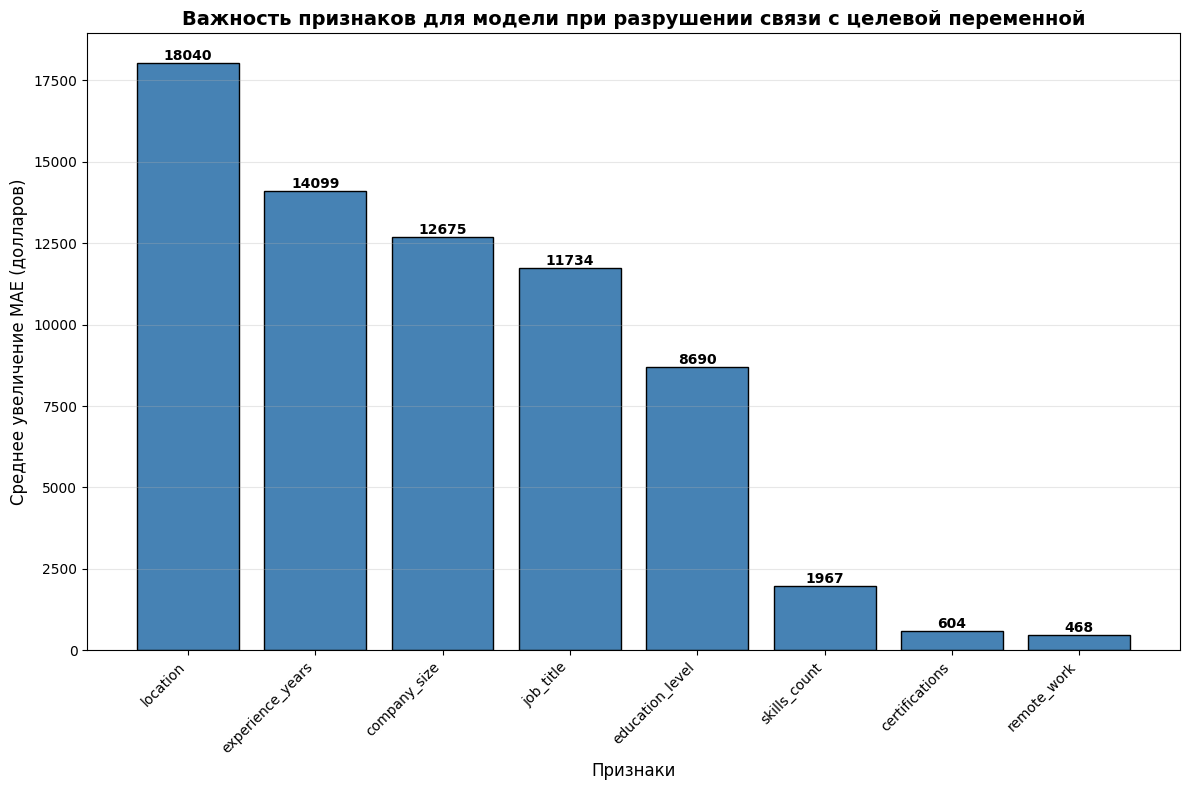

In [13]:
from sklearn.inspection import permutation_importance

# Вычисляем permutation importance для лучшей модели Random Forest
perm_importance = permutation_importance(
    best_rf_model,
    X_test,
    y_test,
    scoring='neg_mean_absolute_error',
    n_repeats=3,
    random_state=2026,
    n_jobs=1
)

# Получаем исходные имена признаков (до предобработки)
feature_names = X_test.columns.tolist()

# Создаём Series: для каждого признака - среднее увеличение MAE (в долларах)
perm_importances = pd.Series(perm_importance.importances_mean, index=feature_names)
perm_importances_sorted = perm_importances.sort_values(ascending=False)

# Визуализация
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(
    range(len(perm_importances_sorted)),
    perm_importances_sorted.values,
    color='steelblue',
    edgecolor='black'
)
ax.set_title("Важность признаков для модели при разрушении связи с целевой переменной", fontsize=14, fontweight='bold')
ax.set_xlabel("Признаки", fontsize=12)
ax.set_ylabel("Среднее увеличение MAE (долларов)", fontsize=12)
ax.set_xticks(range(len(perm_importances_sorted)))
ax.set_xticklabels(perm_importances_sorted.index, rotation=45, ha='right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Добавляем числовые значения над столбцами
for bar, value in zip(bars, perm_importances_sorted.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{value:.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

**Наибольший вклад в точность прогнозирования зарплаты вносят** следующие **признаки: географическое положение, стаж работы, размер компании и должность**. **Разрушение связи переменной location с целевой зарплатой приводит к самому сильному ухудшению качества модели: среднее увеличение MAE составляет 18 040 долларов, что делает локацию самым значимым фактором для модели**. Следом по важности располагаются experience_years с увеличением MAE на 14 099 долларов, company_size с ростом ошибки на 12 675 долларов и job_title с показателем 11 734 доллара. Эти четыре признака являются ключевыми для прогнозирования и определяют основную предсказательную силу модели. **Уровень образования education_level также вносит заметный вклад** (увеличение MAE на 8 690 долларов), однако его влияние несколько уступает перечисленным выше факторам. В противоположность этому, **признаки skills_count** (1 967 долларов), **certifications** (604 доллара) **и remote_work** (468 долларов) **приводят к маленькому увеличению MAE** при перемешивании значений, что **указывает на их слабую значимость для модели**. Количество профессиональных навыков и сертификатов, а также формат работы практически не влияют на точность прогнозов, поскольку их случайное перемешивание почти не ухудшает качество предсказаний. Таким образом, **модель Random Forest при прогнозировании зарплаты в первую очередь опирается на географическую локацию, стаж, размер компании и должность, тогда как навыки, сертификаты и формат работы являются малозначимыми**.

## **Локальная интерпретация предсказаний на отдельных объектах**

**Для локальной интерпретации предсказаний модели Random Forest воспользуемся библиотекой SHAP, которая раскладывает итоговое предсказание на сумму вкладов отдельных признаков**, показывая, на сколько долларов каждый признак увеличивает или уменьшает предсказанную зарплату относительно среднего значения, рассчитанного по обучающей выборке. Из тестовой выборки отберём 3 объекта с разным уровнем зарплат (минимальную, типичную (медиану) и максимальную) и для каждого вычислим SHAP-значения, отражающие вклад признаков в предсказание. Результаты визуализируем с помощью waterfall_plot, который наглядно **показывает, как базовое предсказание модели (средняя зарплата по обучающей выборке) преобразуется в финальное предсказание для конкретного сотрудника с учётом вклада каждого признака**: красные полосы обозначают признаки, увеличивающие зарплату, синие - уменьшающие, а длина каждой полосы пропорциональна величине вклада в долларах. **Такой подход позволяет для каждого из выбранных сотрудников понять, какие именно признаки, в какую сторону и насколько сильно повлияли на предсказанное значение зарплаты**.

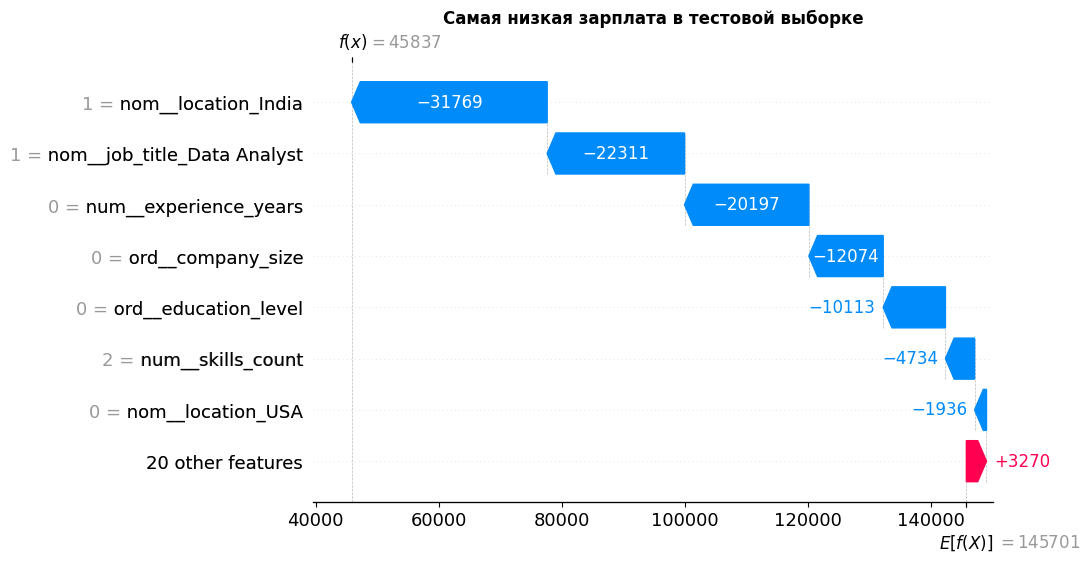

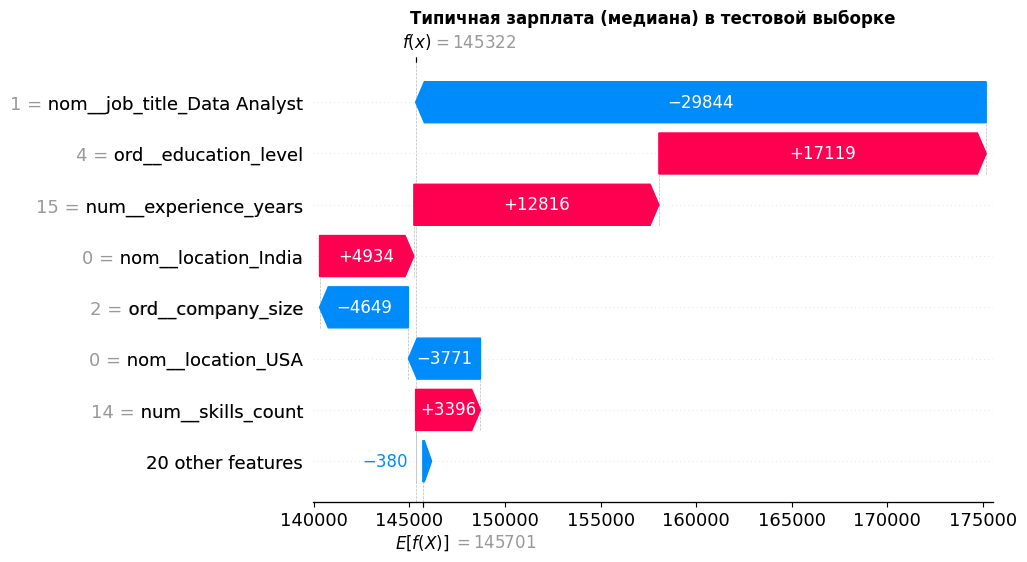

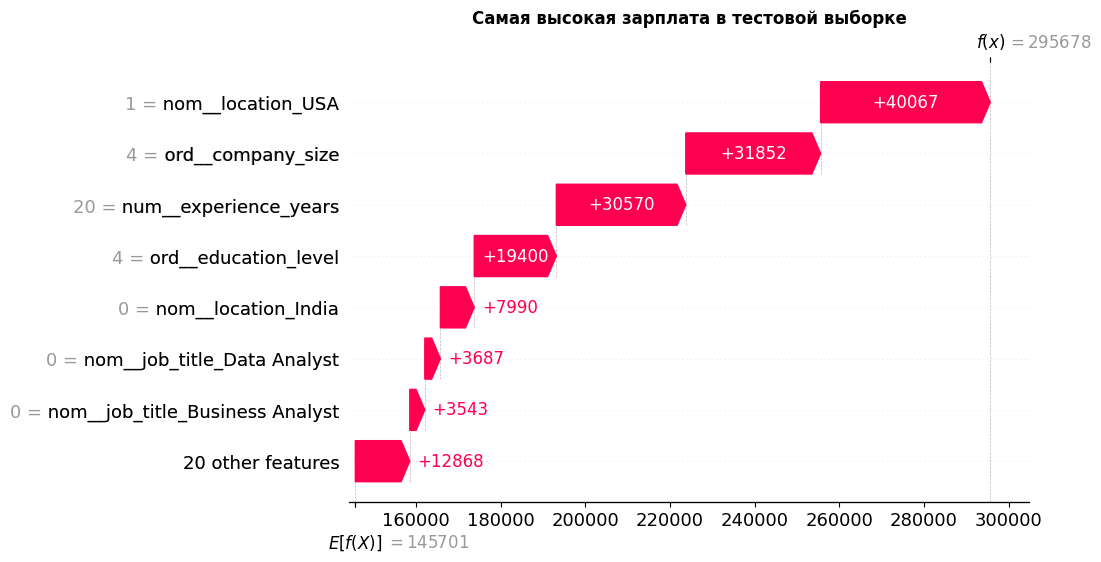

In [14]:
import shap

# TreeExplainer не поддерживает Pipeline, поэтому извлекаем модель Random Forest и препроцессор из пайплайна
rf_model = best_rf_model.named_steps['regressor']
preprocessor = best_rf_model.named_steps['preprocessor']

# Создание SHAP explainer для модели Random Forest
explainer = shap.TreeExplainer(rf_model)

# Сортируем тестовую выборку по целевой переменной (зарплате) по возрастанию
y_test_sorted = y_test.sort_values()
indices_sorted = y_test_sorted.index

# Выбираем 3 объекта с разными зарплатами из тестовой выборки для локальной интерпретации:
selected_indices = [
    indices_sorted[0],                               # Минимум: самая низкая зарплата в выборке
    indices_sorted[int(len(y_test_sorted) * 0.5)],   # Медиана (50-й процентиль): типичная зарплата
    indices_sorted[-1]                               # Максимум: самая высокая зарплата в выборке
]

# Определяем названия категорий для заголовков графиков
categories = [
    "Самая низкая зарплата в тестовой выборке",
    "Типичная зарплата (медиана) в тестовой выборке",
    "Самая высокая зарплата в тестовой выборке"
]

# Получаем имена признаков после предобработки
feature_names = preprocessor.get_feature_names_out()

# Обработка каждого объекта
for i, idx in enumerate(selected_indices):

    # Извлекаем выбранный объект
    instance_raw = X_test.loc[[idx]]

    # Предобрабатываем объект
    instance_preprocessed = preprocessor.transform(instance_raw)

    # Вычисляем SHAP значения для данного объекта: вклад каждого из признаков в предсказание
    shap_values = np.round(explainer.shap_values(instance_preprocessed)[0]).astype(int)
    base_value = round(explainer.expected_value[0])

    # Визуализация
    plt.figure(figsize=(16, 9))
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values,             # массив вкладов признаков в предсказание
            base_values=base_value,         # базовое предсказание модели (среднее предсказание по обучающей выборке)
            data=instance_preprocessed[0],  # значения признаков объекта
            feature_names=feature_names     # имена признаков
        ),
        # Отображаем только топ-8 наиболее влиятельных признаков
        # (остальные суммируются в строку "other features")
        max_display=8,
        show=False
    )

    plt.title(f"{categories[i]}", fontsize=12, fontweight='bold')
    plt.subplots_adjust(left=0.10, right=0.95, top=0.88, bottom=0.08)
    plt.show()

**Объект 1: Самая низкая зарплата в тестовой выборке** (предсказание 45 837 долларов при среднем предсказании 145 701 доллар по всей обучающей выборке). Предсказанная зарплата этого сотрудника почти на 100 тысяч долларов ниже средней, что обусловлено сочетанием крайне неблагоприятных с точки зрения модели факторов. Самый сильный негативный вклад вносит работа в Индии, которая снижает среднее предсказание на 31 769 долларов, отражая низкий уровень зарплат на индийском рынке труда. Вторым по значимости отрицательным фактором выступает должность Data Analyst, уменьшающая прогноз на 22 311 долларов, что говорит о сравнительно невысоком уровне оплаты труда аналитиков данных относительно других IT-специалистов. Нулевой стаж работы сокращает предсказание ещё на 20 197 долларов, поскольку модель ожидает, что начинающие специалисты без опыта получают значительно меньше коллег с опытом работы. Дополнительное негативное влияние оказывают маленький размер компании, соответствующий категории Startup и дающий снижение на 12 074 доллара (company_size = 0), низкий уровень образования, соответствующий High School и снижающий прогноз на 10 113 долларов (education_level = 0), а также наличие всего двух профессиональных навыков, уменьшающих предсказание на 4 734 доллара (skills_count = 2). Таким образом, данный объект представляет собой начинающего аналитика данных без опыта работы со средним общим образованием, трудящегося в индийском стартапе, что закономерно приводит к самому низкому прогнозу зарплаты в выборке.

**Объект 2: Типичная зарплата (медиана) в тестовой выборке** (предсказание 145 322 доллара при среднем предсказании 145 701 доллар). Финальное предсказание для этого сотрудника практически совпадает со средним значением по обучающей выборке, поскольку разнонаправленные вклады признаков взаимно компенсируются. Самый заметный отрицательный вклад вносит должность Data Analyst, снижающая прогноз на 29 844 доллара, что отражает относительно низкую оплату этой профессии. Однако этот негативный эффект почти полностью перекрывается положительным вкладом высокого уровня образования, соответствующего степени PhD и увеличивающего предсказание на 17 119 долларов (education_level = 4), что демонстрирует значительную премию за докторскую степень, а также большим стажем работы в 15 лет, добавляющим ещё 12 816 долларов (experience_years = 15). Работа не в Индии даёт положительный вклад в 4 934 доллара, поскольку отсутствие привязки к низкооплачиваемой стране повышает ожидаемую зарплату. При этом размер компании, соответствующий категории Medium, вносит умеренный отрицательный вклад, уменьшая прогноз на 4 649 долларов (company_size = 2), а работа не в США снижает предсказание на 3 771 доллар. Количество навыков, равное 14, даёт дополнительный прирост к прогнозу в 3 396 долларов (skills_count = 14). В итоге перед нами высокообразованный специалист с докторской степенью и очень опытный аналитик данных с 15-летним стажем и 14 навыками, работающий в средней компании за пределами Индии и США, чья зарплата оказывается практически на уровне среднерыночной.

**Объект 3: Самая высокая зарплата в тестовой выборке** (предсказание 295 678 долларов при среднем предсказании 145 701 доллар). Предсказанная зарплата этого сотрудника более чем вдвое превышает среднее значение по обучающей выборке, что объясняется исключительно благоприятным сочетанием всех ключевых факторов. Самым значимым положительным фактором выступает работа в США, которая увеличивает прогноз на 40 067 долларов, отражая высокий уровень оплаты труда на американском рынке. Второй по величине вклад вносит размер компании, соответствующий категории Enterprise, где принадлежность к корпорации добавляет 31 852 доллара к предсказанию (company_size = 4). Максимальный стаж работы в 20 лет даёт прирост в 30 570 долларов (experience_years = 20), подтверждая, что модель высоко ценит многолетний профессиональный опыт. Высший уровень образования, соответствующий степени PhD, добавляет ещё 19 400 долларов (education_level = 4). Отсутствие работы в Индии также даёт положительный вклад в 7 990 долларов, поскольку модель воспринимает это как преимущество. Работа не на должностях бизнес-аналитика и аналитика данных даёт небольшие положительные вклады в 3 687 и 3 543 доллара соответственно. Совокупность 20 других признаков добавляет ещё 12 868 долларов. Таким образом, данный объект представляет собой высокооплачиваемого специалиста с уникальным сочетанием характеристик: максимальный стаж, докторская степень, работа в американской корпорации, что в совокупности позволяет модели предсказать самую большую зарплату в тестовой выборке.

## **Экспертное мнение о полученной интерпретации**

**Значимость признаков для модели Random Forest логична и соответствует рыночным реалиям: географическое место работы, стаж, размер компании и должность являются главными факторами, определяющими зарплату, поскольку именно они напрямую задают рыночный диапазон оплаты**. Уровень образования оказывает второстепенное влияние, что отражает ситуацию, когда работодатели ценят высокий уровень образования, но практический опыт всё же перевешивает. **Количество навыков и сертификатов ожидаемо оказалось малозначимым, так как их простое число без учёта релевантности, глубины владения и практического применения не является надёжным индикатором реальной квалификации сотрудника**.

**Изучение влияния признаков на формирование предсказаний для отдельных объектов также демонстрирует логичные и согласованные с рыночной логикой решения модели**: работа в Индии закономерно снижает прогноз, отражая более низкий уровень оплаты в этой стране; должность аналитика данных оценивается ниже, чем более специализированные IT-специальности; **отсутствие опыта работы, занятость в стартапе и наличие лишь школьного образования ожидаемо уменьшают предсказанную зарплату, тогда как докторская степень, многолетний стаж и работа в американской корпорации предсказуемо дают сильный положительный вклад, формируя высокий уровень дохода**.

Таким образом, **как глобальные, так и локальные интерпретации показывают, что модель Random Forest принимает логичные решения, соответствующие реальным закономерностям формирования зарплаты на рынке труда**. **Модель корректно выявляет ключевые факторы, влияющие на уровень оплаты, и отражает их вклад в прогноз правдоподобным образом, что свидетельствует о высоком качестве обученной модели**.
